In [ ]:
# 1. Importación de Librerías y Configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import json

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


Directorio de trabajo actual: /workspaces/proyecto-ciberseguridad/analyzer/nbs


In [ ]:
# 2. Carga de Datos
import os
import json
import pandas as pd

DATA_PATH = '../data/miner_dataset.json'

if os.path.exists(DATA_PATH):
    try:
        # Cargar el JSON generado por el Miner
        with open(DATA_PATH, 'r') as file:
            raw_data = json.load(file)
        
        if "vulnerabilities" in raw_data:
            df = pd.DataFrame(raw_data["vulnerabilities"])
        else:
            df = pd.DataFrame(raw_data) # Por si la estructura es plana
            
        print(f"Datos cargados exitosamente. Total de vulnerabilidades: {len(df)}")
        
        # Visualizar las primeras filas solo si se cargó correctamente
        display(df.head())
        
    except Exception as e:
        print(f"Ocurrió un error al cargar los datos: {e}")
else:
    print(f"Error: No se encontró el archivo en {DATA_PATH}.")

Datos cargados exitosamente. Total de vulnerabilidades: 41


,vulnerability_id,type,source_tool,repository,location,severity,description,cwe_id,package_name,installed_version,fixed_version,detected_at
0,GHSA-2g68-c3qc-8985,dependency,grype,flask,/examples/celery/requirements.txt,high,Werkzeug debugger vulnerable to remote executi...,NaN,werkzeug,2.3.3,3.0.3,2026-04-28T16:42:11.167291+00:00
1,GHSA-3936-cmfr-pm3m,dependency,grype,pydantic,/pydantic-core/uv.lock,high,Black: Arbitrary file writes from unsanitized ...,NaN,black,24.10.0,26.3.1,2026-04-28T16:42:12.660574+00:00
2,GHSA-3936-cmfr-pm3m,dependency,grype,pydantic,/uv.lock,high,Black: Arbitrary file writes from unsanitized ...,NaN,black,24.10.0,26.3.1,2026-04-28T16:42:12.660594+00:00
3,GHSA-29vq-49wr-vm6x,dependency,grype,flask,/examples/celery/requirements.txt,medium,Werkzeug safe_join() allows Windows special de...,NaN,werkzeug,2.3.3,3.1.6,2026-04-28T16:42:11.167339+00:00
4,GHSA-6w46-j5rx-g56g,dependency,grype,flask,/uv.lock,medium,pytest has vulnerable tmpdir handling,NaN,pytest,9.0.2,9.0.3,2026-04-28T16:42:11.167342+00:00


In [ ]:
# 3. Inspección Inicial del Dataset
# Ver la estructura, tipos de datos y valores nulos
print("--- Información del DataFrame ---")
df.info()

print("\n--- Valores Nulos por Columna ---")
print(df.isnull().sum())

--- Información del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   vulnerability_id   41 non-null     str  
 1   type               41 non-null     str  
 2   source_tool        41 non-null     str  
 3   repository         41 non-null     str  
 4   location           41 non-null     str  
 5   severity           41 non-null     str  
 6   description        41 non-null     str  
 7   cwe_id             15 non-null     str  
 8   package_name       26 non-null     str  
 9   installed_version  26 non-null     str  
 10  fixed_version      26 non-null     str  
 11  detected_at        41 non-null     str  
dtypes: str(12)
memory usage: 4.0 KB

--- Valores Nulos por Columna ---
vulnerability_id      0
type                  0
source_tool           0
repository            0
location              0
severity              0
description   

/tmp/ipykernel_1101/629937726.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=severity_counts.index, y=severity_counts.values, palette='Reds_r')


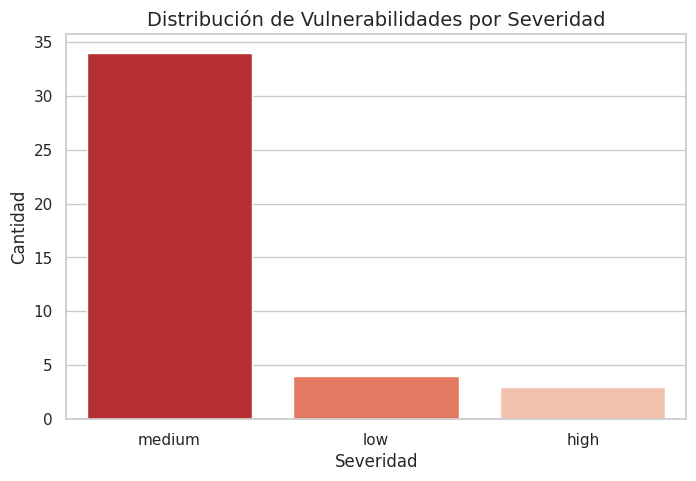

In [ ]:
# 4. Análisis Exploratorio: Severidad
if 'severity' in df.columns:
    severity_counts = df['severity'].value_counts()
    
    # Gráfico de barras con Seaborn
    plt.figure(figsize=(8, 5))
    sns.barplot(x=severity_counts.index, y=severity_counts.values, palette='Reds_r')
    plt.title('Distribución de Vulnerabilidades por Severidad', fontsize=14)
    plt.xlabel('Severidad')
    plt.ylabel('Cantidad')
    plt.show()
else:
    print("La columna 'severity' no existe en el dataset. Verifica los nombres de las columnas.")

In [ ]:
# 5. Análisis Exploratorio: Herramientas (CodeQL vs Grype)

col_tool = 'source_tool' # Ajusta esto según tu JSON

if col_tool in df.columns:
    fig = px.pie(df, names=col_tool, title='Proporción de Vulnerabilidades por Herramienta', hole=0.3)
    fig.show()
else:
    print(f"La columna '{col_tool}' no existe en el dataset.")